In [ ]:

import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 128
# preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
from medmnist.dataset import PathMNIST

# load the data
train_dataset = PathMNIST(split='train', size=224, root="/home/bobsun/cambrige/MedMinist/data",
                          transform=data_transform, download=True)
test_dataset = PathMNIST(split='test', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                         download=True)

# encapsulate data into dataloader form
# train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2 * BATCH_SIZE, shuffle=False)

def test(model, test_loader):
    model.eval()
    test_total = 0
    test_correct = 0
    # Disable gradient calculation for faster inference
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long()
            # Forward pass
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            # Update correct and total counts
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()

    # Calculate accuracy
    test_accuracy = 100 * test_correct / test_total
    print(f'Test Accuracy: {test_accuracy:.2f}%')
    return test_accuracy

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pathmnist_224.npz


In [3]:
from torch import nn
import torch
from MedMinist.resnet import no_inplace_resnet18
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载原始模型
original_model = torch.load('pathmnist_resnet_94.92.pth', map_location='cpu')

# 创建新的模型实例
num_classes = 9  # 根据您的任务设置类别数量
model = no_inplace_resnet18(num_classes=num_classes)
model = model.to(device)

# 从原始模型中提取 state_dict
if isinstance(original_model, nn.Module):
    original_state_dict = original_model.state_dict()
elif isinstance(original_model, dict):
    original_state_dict = original_model
else:
    raise TypeError("Unsupported model format.")

# 处理键名不匹配的问题（如果有必要）
new_state_dict = model.state_dict()
for key in new_state_dict.keys():
    if key in original_state_dict and new_state_dict[key].shape == original_state_dict[key].shape:
        new_state_dict[key] = original_state_dict[key]
    else:
        print(f"Skipping parameter {key}")

# 将处理后的 state_dict 加载到新的模型中
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [3]:
test_accuracy = test(model, test_loader)

Test Accuracy: 94.92%


In [1]:
from medmnist import INFO
import torch
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
from PIL import Image

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

idx = 4

# 定义生成 Grad-CAM 热力图的函数
def generate_grad_cam(model, input_tensor, class_idx):
    # 初始化 GradCAM 对象
    cam_extractor = GradCAM(model, target_layer=model.layer4)
    # 获取模型输出
    out = model(input_tensor)
    # 生成指定类别的 CAM 热力图
    activation_map = cam_extractor(class_idx, out)
    return activation_map


# 加载模型并设置为评估模式
model.eval()
model.to(device)

# 选择目标层
target_layer = 'layer4'  # 以 ResNet18 为例

# 从 test_loader 中获取一批图像
images, labels = next(iter(test_loader))

# 获取单张图像并处理
img_tensor = images[idx].to(device)  # 选择 batch 中的第一张图像
# 如果是单通道图像，转换为三通道
if img_tensor.shape[0] == 1:
    img_tensor = img_tensor.repeat(3, 1, 1)
# 添加批次维度
input_tensor = img_tensor.unsqueeze(0)

# 获取模型输出并预测类别
output = model(input_tensor)
predicted_class = output.argmax(dim=1).item()  # 获取预测的类别索引

# 生成 Grad-CAM 热力图
activation_map = generate_grad_cam(model, input_tensor, labels[idx].item())
# activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min())
# 将输入张量转换为 PIL 图像以便可视化
input_image = to_pil_image(img_tensor.cpu() * 0.5 + 0.5)

# 可视化结果
activation_map = activation_map[0].squeeze().cpu().detach().numpy()
# result = visualize_cam_on_image(input_image, activation_map)
result = overlay_mask(input_image, Image.fromarray(activation_map, mode='F'), alpha=0.5)


class_names = [label for _, label in INFO["pathmnist"]["label"].items()]
print(class_names[labels[idx].item()])
# 显示或保存结果
result
# 或者保存图像
# result.save('grad_cam_result.jpg')

NameError: name 'model' is not defined

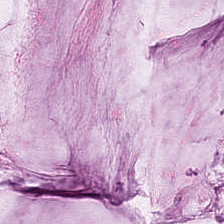

In [56]:
input_image

In [27]:
activation_map

[tensor([[[0.3399, 0.4226, 0.1237, 0.0000, 0.2136, 0.5194, 0.4376],
          [0.5684, 0.6844, 0.2987, 0.1737, 0.3537, 0.6677, 0.5337],
          [0.5494, 0.7949, 0.4249, 0.2269, 0.2227, 0.3933, 0.3009],
          [0.5624, 0.8905, 0.5601, 0.4253, 0.3153, 0.2754, 0.1448],
          [0.4333, 0.8333, 0.7628, 0.6753, 0.6590, 0.5991, 0.3809],
          [0.4962, 1.0000, 0.9744, 0.9583, 0.9340, 0.7878, 0.4918],
          [0.3344, 0.7019, 0.6912, 0.7248, 0.7390, 0.6514, 0.4125]]],
        device='cuda:0')]

In [24]:
print(model)

NoInplaceResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): NoInplaceBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): NoInplaceBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv